# MS 3313 — Comprehensive Final Exam

## Modules 1–5 (R Basics → ML Basics → ANOVA/MANOVA → Dimension Reduction → KNN → Factor & Conjoint → Clustering → Discriminant Analysis)

**Course:** MS3313  
**Final:** Cumulative — covers every technical area in the lecture notebooks.

---

### Instructions

This notebook contains **eight questions**. For each question:

- Code cells already define the **dataset name**, **input variable name (X)**, and **output / model object name** you must use. **Do not rename them — graders look for these specific names.**
- Wherever you see `# YOUR CODE HERE — delete this comment when you add your code`, replace that line with your solution.
- Wherever you see `NULL    # replace NULL with your code`, replace `NULL` with your working expression.
- After each question, an **analysis answer** markdown cell is provided. Replace `*Your answer here*` with your written interpretation (3–6 sentences).
- All datasets come from the **`mlba`** package — no external CSVs needed.
- Use `set.seed(42)` whenever a partition / random start is required (already provided).

### Required object names

| Q | Module | Dataframe | Inputs (X) / Model | Output / Result |
|---|--------|-----------|--------------------|-----------------|
| 1 | M1 — ML basics | `air.df` | `X_air`, `train.df`, `valid.df`, `fare.lm` | `Y_fare_pred`, `rmse_fare`, `mae_fare`, `mape_fare` |
| 2 | M2 — ANOVA/MANOVA | `flights.df` | `aov_dep`, `tukey_dep`, `levene_dep`, `manova_flights` | (built-in objects) |
| 3 | M3 — Dimension reduction | `uni.df` | `pca_cov`, `pca_cor` | `n_pcs_kaiser` |
| 4 | M4.0 — KNN | `tayko.df` | `tayko_train`, `tayko_valid`, `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko` | `acc_tayko`, `best_k_tayko`, `Y_tayko_pred`, `cm_tayko` |
| 5 | M4.1a — Factor analysis | `books.df` | `X_books_norm`, `fa_books` | `kmo_books`, `bartlett_books` |
| 6 | M4.1b — Conjoint | `profiles.df` | `cj_lm`, `partworth` | `attr_importance` |
| 7 | M5.0 — Clustering | `ewa.df` | `X_ewa_norm`, `d_ewa`, `hc_ewa`, `km_ewa` | `Y_ewa_hier`, `Y_ewa_km`, `ewa_profile` |
| 8 | M5.1 — LDA | `banks.df` | `X_banks`, `Y_banks`, `lda_banks` | `Y_banks_pred`, `cm_banks`, `accuracy_banks`, `new_bank`, `pred_new_bank` |

---


## Setup: Load Required Libraries

Run this cell as-is. Do **not** modify.

In [1]:
suppressPackageStartupMessages({
  library(mlba)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(caret)
  library(class)         # knn()
  library(MASS)          # lda()
  library(psych)         # KMO, cortest.bartlett, fa.parallel, fa
  library(GPArotation)
  library(car)           # leveneTest
  library(cluster)
  library(factoextra)
  library(conjoint)
  library(fastDummies)
  library(IRdisplay)
})

# dplyr::select wins after MASS is loaded
select <- dplyr::select

set.seed(42)
options(scipen = 999, digits = 4)


## Plot rendering — make charts legible

The default Jupyter R kernel often renders ggplot / `factoextra` figures
with a device that produces tiny or blurry axis text. **Every plot in this
exam must be drawn through a cairo PNG device** so axes, titles, and
legends are readable. The pattern is already provided in each plotting
cell — you only have to drop your plotting expression into the marked
spot:

```r
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
  NULL    # replace NULL with your ggplot / fviz_* / plot(...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)
```

**Hints**

* For `print({ ... })` you may pass a single ggplot or `fviz_*` object.
* For base-graphics calls (e.g., `plot(hc); rect.hclust(...)`) put the
  drawing commands *between* `png(...)` and `dev.off()` — no `print()` needed.
* Keep `res = 120` and `family = "sans"` so the rendered fonts match the
  rest of the exam.


---
## Question 1 — Module 1: Multiple Linear Regression on Airfares

**Dataset:** `mlba::Airfares` (638 routes × 18 variables)

**Inputs (X):** all route variables after dropping the four ID/text columns
(`S_CODE`, `S_CITY`, `E_CODE`, `E_CITY`) and dummy-encoding the four categorical
predictors (`VACATION`, `SW`, `SLOT`, `GATE`).

**Output (Y):** `FARE` (average fare in dollars).

**Tasks:**
1. Load the data, drop the four ID columns, and dummy-encode the four categoricals → store the cleaned data in `air.df` and the predictor matrix in `X_air`
2. Partition 60% training / 40% validation with `set.seed(42)` → store in `train.df` and `valid.df`
3. Fit a multiple linear regression `FARE ~ .` on the training set → store in `fare.lm`
4. Predict on the validation set → store predictions in `Y_fare_pred`
5. Compute validation **RMSE**, **MAE**, and **MAPE** → store in `rmse_fare`, `mae_fare`, `mape_fare`
6. Identify the two predictors with the largest absolute *t*-statistic → store in `top2_air`
7. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data, Drop ID Columns, Dummy-Encode

Use `air.df` for the cleaned dataframe and `X_air` for the predictor matrix.

In [2]:
# Required objects: air.df, X_air

air.df <- mlba::Airfares %>%   
select(-S_CODE, -S_CITY, -E_CODE, -E_CITY) %>%
fastDummies::dummy_cols(select_columns = c("VACATION", "SW", "SLOT", "GATE"), remove_first_dummy = TRUE, remove_selected_columns = TRUE)

X_air  <- air.df %>% select(-FARE)

cat("Rows:", nrow(air.df), " Columns:", ncol(air.df), "\n")
str(air.df)


Rows: 638  Columns: 14 
'data.frame':	638 obs. of  14 variables:
 $ COUPON      : num  1 1.06 1.06 1.06 1.06 1.01 1.28 1.15 1.33 1.6 ...
 $ NEW         : int  3 3 3 3 3 3 3 3 3 2 ...
 $ HI          : num  5292 5419 9185 2657 2657 ...
 $ S_INCOME    : num  28637 26993 30124 29260 29260 ...
 $ E_INCOME    : num  21112 29838 29838 29838 29838 ...
 $ S_POP       : int  3036732 3532657 5787293 7830332 7830332 2230955 3036732 1440377 3770125 1694803 ...
 $ E_POP       : int  205711 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 ...
 $ DISTANCE    : int  312 576 364 612 612 309 1220 921 1249 964 ...
 $ PAX         : int  7864 8820 6452 25144 25144 13386 4625 5512 7811 4657 ...
 $ FARE        : num  64.1 174.5 207.8 85.5 85.5 ...
 $ VACATION_Yes: int  0 0 0 0 0 0 0 1 0 0 ...
 $ SW_Yes      : int  1 0 0 1 1 1 0 1 1 1 ...
 $ SLOT_Free   : int  1 1 1 0 1 1 1 1 1 1 ...
 $ GATE_Free   : int  1 1 1 1 1 1 1 1 1 1 ...


### Step 2 — 60/40 Train/Validation Partition

Store the partitions in `train.df` and `valid.df`.

In [3]:
set.seed(42)
# Required objects: train.df, valid.df

train_idx <- sample(seq_len(nrow(air.df)), size = floor(0.6 * nrow(air.df)))    # replace NULL with your code
train.df  <- air.df[ train_idx, ]    # replace NULL with your code
valid.df  <- air.df[-train_idx, ]    # replace NULL with your code

cat("train rows:", nrow(train.df), " valid rows:", nrow(valid.df), "\n")


train rows: 382  valid rows: 256 


### Step 3 — Fit the Multiple Linear Regression

Fit `FARE ~ .` on the training set; store the model in `fare.lm`.

In [4]:
# Required object: fare.lm

fare.lm <- lm(FARE ~ ., data = train.df)    # replace NULL with your code

summary(fare.lm)



Call:
lm(formula = FARE ~ ., data = train.df)

Residuals:
   Min     1Q Median     3Q    Max 
-99.82 -23.15  -3.16  22.80 105.85 

Coefficients:
                  Estimate    Std. Error t value             Pr(>|t|)    
(Intercept)   -0.485813647  37.446794886   -0.01               0.9897    
COUPON        25.847265367  16.472312861    1.57               0.1175    
NEW           -2.173578494   2.623328899   -0.83               0.4079    
HI             0.008342867   0.001328067    6.28    0.000000000944278 ***
S_INCOME       0.000884957   0.000699365    1.27               0.2065    
E_INCOME       0.001367974   0.000487048    2.81               0.0052 ** 
S_POP          0.000003677   0.000000881    4.17    0.000037450776099 ***
E_POP          0.000004415   0.000001006    4.39    0.000014918750109 ***
DISTANCE       0.067187479   0.004770719   14.08 < 0.0000000000000002 ***
PAX           -0.000706558   0.000197688   -3.57               0.0004 ***
VACATION_Yes -38.553667684   4.868524027

### Step 4 — Predict on the Validation Set

Store the predicted fares in `Y_fare_pred`.

In [5]:
# Required object: Y_fare_pred

Y_fare_pred <- predict(fare.lm, newdata = valid.df )    # replace NULL with your code

head(Y_fare_pred)


1      4      5      6      7      8 
 69.40 133.88 117.67  87.16 232.20 114.78

### Step 5 — Compute Validation RMSE, MAE, and MAPE

Store the metrics in `rmse_fare`, `mae_fare`, `mape_fare`.

In [6]:
# Required objects: rmse_fare, mae_fare, mape_fare


rmse_fare <- sqrt(mean((valid.df$FARE - Y_fare_pred)^2))    # replace NULL with your code
mae_fare  <- mean(abs(valid.df$FARE - Y_fare_pred))    # replace NULL with your code
mape_fare <- mean(abs((valid.df$FARE - Y_fare_pred) / valid.df$FARE)) * 100    # replace NULL with your code  # express MAPE as a percentage

cat(sprintf("RMSE = %.3f\nMAE  = %.3f\nMAPE = %.3f%%\n",
            rmse_fare, mae_fare, mape_fare))


RMSE = 34.157
MAE  = 26.686
MAPE = 20.506%


### Step 6 — Top 2 Most Influential Predictors (Largest |t|)

Store the two top rows of the coefficient table in `top2_air`.

In [7]:
# Required object: top2_air
coef_table <- summary(fare.lm)$coefficients
coef_no_intercept <- coef_table[rownames(coef_table) != "(Intercept)", ]
top2_air <- coef_no_intercept[order(-abs(coef_no_intercept[, "t value"])), ][1:2, ]    # replace NULL with your code
top2_air


,Estimate,Std. Error,t value,Pr(>|t|)
DISTANCE,0.06719,0.004771,14.083,0.000000000000000000000000000000000002479
VACATION_Yes,-38.55367,4.868524,-7.919,0.000000000000028607342042521423053973911


### Question 1 — Analysis Answer

*The model predicts airfares with a validation RMSE of $34.16, MAE of $26.69, MAPE 20.5%.  On average the model predicsts the fare within $27 and the stongest predictors are "Distance"(t = 14.08) and "Vacation_Yes"(t = -7.92).  The distance adds almost $0.07 per mile for the fare and the destinations that are likly vacation spots are around $39 cheaper.  While a MAPE of 20% isnt great it works but I think the model could be improved more.*

---


## Question 2 — Module 2: ANOVA & MANOVA on Flight Delays

**Dataset:** `mlba::FlightDelays` (2,201 flights × 13 variables)

**Tasks:**
1. Load the data, convert `CARRIER`, `DAY_WEEK`, and `Flight.Status` to factors → store in `flights.df`
2. Run a one-way **ANOVA**: does `CRS_DEP_TIME` differ across `CARRIER`? → store the model in `aov_dep`
3. Run **Tukey HSD** post-hoc on `aov_dep` → store in `tukey_dep`
4. Test homogeneity of variance with **Levene's test** (`car::leveneTest`) → store in `levene_dep`
5. Run a one-way **MANOVA**: do `CRS_DEP_TIME` and `DISTANCE` jointly differ across `DAY_WEEK`? → store in `manova_flights`; report **Pillai's trace**
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data and Set Factor Types

Store the cleaned dataframe in `flights.df`.

In [8]:
# Required object: flights.df
flights.df <- mlba::FlightDelays %>%
  mutate(
    CARRIER       = factor(CARRIER),
    DAY_WEEK      = factor(DAY_WEEK),
    Flight.Status = factor(Flight.Status))

cat("n =", nrow(flights.df), "  carriers =", nlevels(flights.df$CARRIER), "\n")
table(flights.df$CARRIER)    # replace NULL with your code

cat("n =", nrow(flights.df), "  carriers =", nlevels(flights.df$CARRIER), "\n")
table(flights.df$CARRIER)

n = 2201   carriers = 8 



 CO  DH  DL  MQ  OH  RU  UA  US 
 94 551 388 295  30 408  31 404 

n = 2201   carriers = 8 



 CO  DH  DL  MQ  OH  RU  UA  US 
 94 551 388 295  30 408  31 404 

### Step 2 — One-Way ANOVA: `CRS_DEP_TIME ~ CARRIER`

Store the ANOVA model in `aov_dep`.

In [9]:
# Required object: aov_dep
aov_dep <- aov(CRS_DEP_TIME ~ CARRIER, data = flights.df)    # replace NULL with your code
summary(aov_dep)


              Df    Sum Sq Mean Sq F value           Pr(>F)    
CARRIER        7  13475003 1925000    10.6 0.00000000000036 ***
Residuals   2193 398424008  181680                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Step 3 — Tukey HSD Post-Hoc

Store the result in `tukey_dep` and show the five smallest adjusted *p*-values.

In [10]:
# Required object: tukey_dep

tukey_dep <- TukeyHSD(aov_dep)    # replace NULL with your code
head(tukey_dep$CARRIER[order(tukey_dep$CARRIER[,"p adj"]), ], 5)


,diff,lwr,upr,p adj
UA-DH,-598.7,-837.4,-360.0,0.00000000006457
UA-DL,-519.4,-760.7,-278.0,0.00000000236566
US-UA,513.4,272.4,754.4,0.00000000360199
UA-CO,-569.5,-837.3,-301.7,0.00000000387473
UA-RU,-494.5,-735.4,-253.6,0.00000001596055


### Step 4 — Levene's Test for Homogeneity of Variance

Store the test result in `levene_dep`.

In [11]:
# Required object: levene_dep

levene_dep <- car::leveneTest(CRS_DEP_TIME ~ CARRIER, data = flights.df)    # replace NULL with your code
levene_dep


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,7,19.69,0.00000000000000000000000009907
,2193,NA,NA


### Step 5 — One-Way MANOVA: `cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK`

Store the MANOVA in `manova_flights` and report Pillai's trace.

In [12]:
# Required object: manova_flights

manova_flights <- manova(cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK, data = flights.df)    # replace NULL with your code

summary(manova_flights, test = "Pillai")
summary.aov(manova_flights)   # univariate follow-ups


            Df  Pillai approx F num Df den Df Pr(>F)
DAY_WEEK     6 0.00786     1.44     12   4388   0.14
Residuals 2194                                      

 Response CRS_DEP_TIME :
              Df    Sum Sq Mean Sq F value Pr(>F)  
DAY_WEEK       6   2822921  470487    2.52  0.019 *
Residuals   2194 409076090  186452                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response DISTANCE :
              Df Sum Sq Mean Sq F value Pr(>F)
DAY_WEEK       6    382    63.7    0.36   0.91
Residuals   2194 389761   177.6               


### Question 2 — Analysis Answer

*Each carrier has their time that they are busiest, with UA scheduling deparetures the earliest.  They differ significantly beacuse the F=10.6 and the p < 0.001 are significant. It is harder to schedule with the days of the week, becuase the departure day of the week have unequal variations. The airport is better off scheduling during the peak times of the carriers instead of the day of the week. *

---


## Question 3 — Module 3: PCA on Universities

**Dataset:** `mlba::Universities` (1,302 universities × 20 variables)

**Inputs (X):** the 17 numeric metrics — drop `College.Name`, `State`, and the
binary public/private flag, then drop rows with any `NA`.

**Tasks:**
1. Load the data, drop the three non-numeric columns, drop rows with any `NA` → store in `uni.df`
2. Run PCA on the **covariance** matrix (raw scale) → store in `pca_cov`
3. Run PCA on the **correlation** matrix (`scale. = TRUE`) → store in `pca_cor`
4. Apply the **Kaiser rule** (eigenvalue ≥ 1) on `pca_cor` → store the count in `n_pcs_kaiser`; report the cumulative variance explained
5. Plot the **scree plot** and the **PC1–PC2 biplot** of `pca_cor`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store the cleaned numeric dataframe in `uni.df`.

In [13]:
# Required object: uni.df

uni.df <- mlba::Universities %>%
  select(-College.Name, -State) %>%
  select(where(is.numeric)) %>%
  select(-starts_with("Public")) %>%
  na.omit()

cat("n =", nrow(uni.df), "  p =", ncol(uni.df), "\n")

n = 471   p = 17 


### Step 2 — PCA on the Covariance Matrix

Store in `pca_cov`. (Use `prcomp` with `scale. = FALSE`.)

In [14]:
# Required object: pca_cov

pca_cov <- prcomp(uni.df, scale. = FALSE)    # replace NULL with your code
round(summary(pca_cov)$importance[, 1:5], 4)


,PC1,PC2,PC3,PC4,PC5
Standard deviation,7430.9140,5987.9890,1854.6412,1192.5293,967.4279
Proportion of Variance,0.5614,0.3645,0.0350,0.0145,0.0095
Cumulative Proportion,0.5614,0.9259,0.9609,0.9753,0.9848


### Step 3 — PCA on the Correlation Matrix (Standardized)

Store in `pca_cor`. (Use `prcomp` with `scale. = TRUE`.)

In [15]:
# Required object: pca_cor

pca_cor <- prcomp(uni.df, scale. = TRUE)    # replace NULL with your code
round(summary(pca_cor)$importance[, 1:6], 4)


,PC1,PC2,PC3,PC4,PC5,PC6
Standard deviation,2.2749,2.1426,1.0984,1.0325,0.9760,0.8728
Proportion of Variance,0.3044,0.2700,0.0710,0.0627,0.0560,0.0448
Cumulative Proportion,0.3044,0.5745,0.6454,0.7081,0.7642,0.8090


### Step 4 — Kaiser Rule

Store the number of components retained in `n_pcs_kaiser`.

In [16]:
# Required object: n_pcs_kaiser

eig <- pca_cor$sdev^2
n_pcs_kaiser <- sum(eig >= 1)
cat("Kaiser keeps", n_pcs_kaiser, "PCs\n")
cat("Cumulative variance explained =",
    round(sum(eig[seq_len(n_pcs_kaiser)]) / sum(eig), 3), "\n")


Kaiser keeps 4 PCs
Cumulative variance explained = 0.708 


### Step 5 — Scree Plot and PC1–PC2 Biplot

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


agg_record_1831647402 
                    2

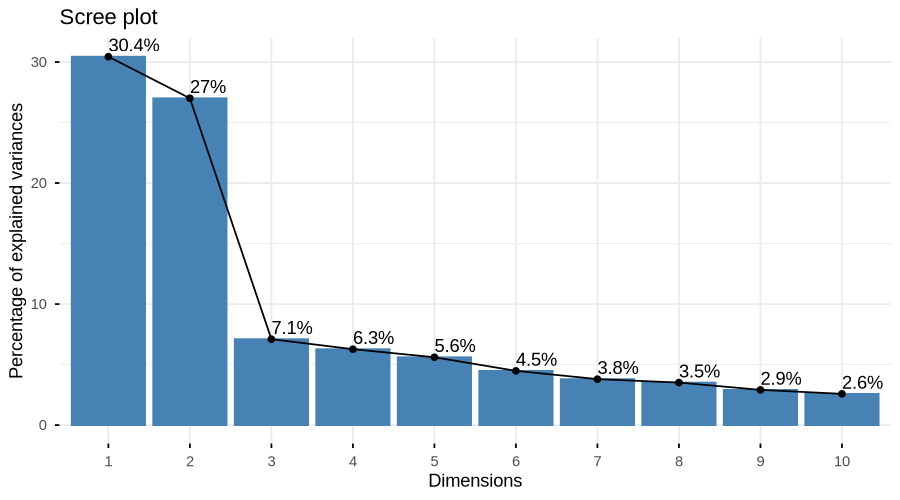

In [17]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 500, res = 120,
    type = "cairo", family = "sans")

# Build a fviz_eig(...) scree plot inside print(...).

print(
  factoextra::fviz_eig(pca_cor, addlabels = TRUE, ncp = 10)
)

dev.off()
IRdisplay::display_png(file = tmp_file)


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


agg_record_1033320285 
                    2

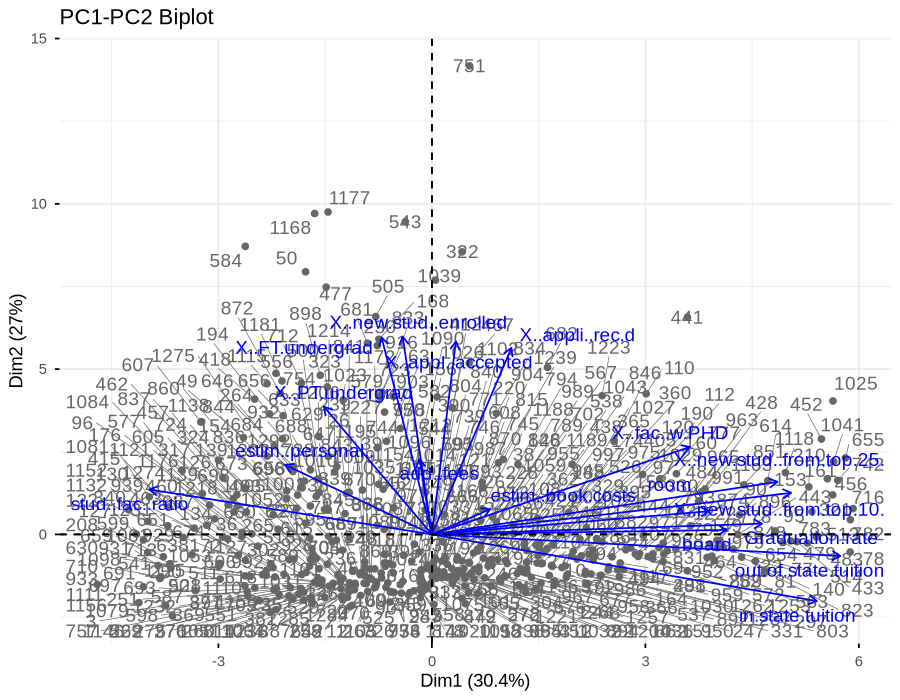

In [18]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 700, res = 120,
    type = "cairo", family = "sans")

# Build a fviz_pca_biplot(...) plot of pca_cor inside print(...).

print(
  factoextra::fviz_pca_biplot(pca_cor, repel = TRUE, col.var = "blue", col.ind = "gray40", title = "PC1-PC2 Biplot"))

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 3 — Analysis Answer

*PCA in the covariance matrix has only 2 components explaining 92.6% of the variance. That doesn't really make a great fit for the model, which is why the PCA in the correlation matrix is better with PC1 explaining 30.4%, and PC2 explaining 27% of variance. After the Kaiser Rule, it kept 4 components, with those 4 explaining 70.8% of the total variance. One key bussiness take away is that colleges can be ranked more easily now. Instead of 17 components, it can be narrowed down to 4 major ones that explain most of the variacne.  These are the main reasons someone would choose this school.*

---


## Question 4 — Module 4.0: K-Nearest Neighbors on Tayko

**Dataset:** `mlba::Tayko` (2,000 catalog customers × 25 variables)

**Inputs (X):** all variables except `sequence_number` and `Spending`
(`Spending` is target leakage: `Spending > 0` ⇒ `Purchase = 1`).

**Output (Y):** `Purchase` as a factor with levels `c("No", "Yes")`.

**Tasks:**
1. Load the data, drop `sequence_number` and `Spending`, factor `Purchase` → store in `tayko.df`
2. Partition 60/40 with `set.seed(42)` → store in `tayko_train` and `tayko_valid`
3. Standardize using **training-set statistics only** (`caret::preProcess`) → store in `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko`
4. Tune `k` over `1:15` using `class::knn` and validation accuracy → store the table in `acc_tayko` and the best `k` in `best_k_tayko`
5. Refit at `k = best_k_tayko`, store predictions in `Y_tayko_pred` and the confusion matrix in `cm_tayko`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store in `tayko.df`. Make `Purchase` a factor with levels `c("No", "Yes")`.

In [19]:
# Required object: tayko.df

tayko.df <- mlba::Tayko %>%
select(-sequence_number, -Spending) %>%
mutate(Purchase = factor(Purchase, levels = c(0,1), labels = c("No", "Yes")))    # replace NULL with your code

cat("Rows:", nrow(tayko.df), "  Columns:", ncol(tayko.df), "\n")
table(tayko.df$Purchase)


Rows: 2000   Columns: 23 



  No  Yes 
1000 1000 

### Step 2 — 60/40 Partition

Store in `tayko_train` and `tayko_valid`.

In [20]:
set.seed(42)
# Required objects: tayko_train, tayko_valid

train_idx    <- sample(seq_len(nrow(tayko.df)), size = floor(0.60 * nrow(tayko.df)))    # replace NULL with your code
tayko_train  <- tayko.df[train_idx, ]    # replace NULL with your code
tayko_valid  <- tayko.df[-train_idx, ]    # replace NULL with your code

cat("train:", nrow(tayko_train), "  valid:", nrow(tayko_valid), "\n")


train: 1200   valid: 800 


### Step 3 — Standardize Predictors (Training Stats Only)

Store predictor matrices in `train_X_tayko`, `valid_X_tayko` and labels in
`train_y_tayko`, `valid_y_tayko`. Use `caret::preProcess(method = c("center","scale"))`.

In [21]:
# Required objects: pp_tayko, train_X_tayko, valid_X_tayko, train_y_tayko, valid_y_tayko

pp_tayko      <- caret::preProcess(tayko_train %>% select(-Purchase),
                               method = c("center", "scale"))           # replace NULL with your code  (preProcess on training X)
train_X_tayko <- predict(pp_tayko, tayko_train %>% select(-Purchase))   # replace NULL with your code
valid_X_tayko <- predict(pp_tayko, tayko_valid %>% select(-Purchase))   # replace NULL with your code
train_y_tayko <- tayko_train$Purchase    # replace NULL with your code
valid_y_tayko <- tayko_valid$Purchase    # replace NULL with your code

cat("Train means (should be ~0):\n"); print(round(colMeans(train_X_tayko), 3))


Train means (should be ~0):
                  US             source_a             source_c 
                   0                    0                    0 
            source_b             source_d             source_e 
                   0                    0                    0 
            source_m             source_o             source_h 
                   0                    0                    0 
            source_r             source_s             source_t 
                   0                    0                    0 
            source_u             source_p             source_x 
                   0                    0                    0 
            source_w                 Freq last_update_days_ago 
                   0                    0                    0 
X1st_update_days_ago            Web.order          Gender.male 
                   0                    0                    0 
      Address_is_res 
                   0 


### Step 4 — Tune `k` over 1..15

Store the per-k accuracy table in `acc_tayko` and the best `k` in `best_k_tayko`.

In [22]:
# Required objects: acc_tayko, best_k_tayko

acc_tayko    <- data.frame(k = 1:15, accuracy = NA)    # replace NULL with your code  (data.frame with columns k, accuracy)
for (i in 1:15) {
  pred <- class::knn(train = train_X_tayko,
                     test  = valid_X_tayko,
                     cl    = train_y_tayko,
                     k     = i)
  acc_tayko$accuracy[i] <- mean(pred == valid_y_tayko)
}
best_k_tayko <- acc_tayko$k[which.max(acc_tayko$accuracy)]    # replace NULL with your code

print(acc_tayko)
cat("Best k =", best_k_tayko,
    "  validation accuracy =", round(max(acc_tayko$accuracy), 4), "\n")


    k accuracy
1   1   0.7425
2   2   0.7388
3   3   0.7575
4   4   0.7512
5   5   0.7438
6   6   0.7575
7   7   0.7525
8   8   0.7512
9   9   0.7425
10 10   0.7375
11 11   0.7425
12 12   0.7412
13 13   0.7438
14 14   0.7400
15 15   0.7450
Best k = 3   validation accuracy = 0.7575 


### Step 5 — Final Confusion Matrix at `best_k_tayko`

Store predictions in `Y_tayko_pred` and the `caret::confusionMatrix` object in `cm_tayko`.

In [23]:
# Required objects: Y_tayko_pred, cm_tayko

Y_tayko_pred <- class::knn(train = train_X_tayko,
                            test  = valid_X_tayko,
                            cl    = train_y_tayko,
                            k     = best_k_tayko)         # replace NULL with your code
cm_tayko     <- caret::confusionMatrix(Y_tayko_pred, valid_y_tayko,
                                    positive = "Yes")     # replace NULL with your code  (use positive = "Yes")

cm_tayko


Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  314  98
       Yes  96 292
                                             
               Accuracy : 0.757              
                 95% CI : (0.726, 0.787)     
    No Information Rate : 0.512              
    P-Value [Acc > NIR] : <0.0000000000000002
                                             
                  Kappa : 0.515              
                                             
 Mcnemar's Test P-Value : 0.943              
                                             
            Sensitivity : 0.749              
            Specificity : 0.766              
         Pos Pred Value : 0.753              
         Neg Pred Value : 0.762              
             Prevalence : 0.487              
         Detection Rate : 0.365              
   Detection Prevalence : 0.485              
      Balanced Accuracy : 0.757              
                                             
       'Positive

### Question 4 — Analysis Answer

*KNN was tuned k=1 to 15, and k 3 was the strongest for validation because it had an accuracy of about 75.7%. The confusion matrix correctly predicted 314 non-purchasers, and 291 purchasers with a sensitivity of 74.6% and a specificity of 76.6%.  Tayko can use this data to get more customers by marketing and mailing to the customers who are more likely to purchase from them and spend less on the non-purchasers.*

---


## Question 5 — Module 4.1a: Factor Analysis on Charles Book Club

**Dataset:** `mlba::CharlesBookClub` (4,000 members × 24 variables)

**Inputs (X):** the 8 book-category purchase counts —
`ChildBks, YouthBks, CookBks, DoItYBks, RefBks, ArtBks, GeogBks, ItalCook`.

**Tasks:**
1. Subset to the 8 book-category columns → store in `books.df`
2. Standardize with `scale()` → store in `X_books_norm`
3. Verify factorability: **KMO** (`psych::KMO`) → store in `kmo_books`; **Bartlett's sphericity test** (`psych::cortest.bartlett`) → store in `bartlett_books`
4. Run a parallel-analysis scree plot (`fa.parallel`) to choose the number of factors
5. Run an **EFA with varimax rotation** (`psych::fa`) at `nfactors = 2` → store in `fa_books`; print loadings ≥ 0.30
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 & 2 — Subset and Standardize

Store the 8-column dataframe in `books.df` and the standardized matrix in `X_books_norm`.

In [24]:
# Required objects: books.df, X_books_norm

book_vars <- c("ChildBks","YouthBks","CookBks","DoItYBks",
               "RefBks","ArtBks","GeogBks","ItalCook")

books.df     <- mlba::CharlesBookClub %>% select(all_of(book_vars))    # replace NULL with your code
X_books_norm <- scale(books.df)    # replace NULL with your code

cat("n =", nrow(books.df), " variables =", ncol(books.df), "\n")


n = 4000  variables = 8 


### Step 3 — KMO and Bartlett's Sphericity Test

Store in `kmo_books` and `bartlett_books`.

In [25]:
# Required objects: kmo_books, bartlett_books

kmo_books      <- psych::KMO(X_books_norm)    # replace NULL with your code  (psych::KMO)
bartlett_books <- psych::cortest.bartlett(cor(X_books_norm), n = nrow(X_books_norm))    # replace NULL with your code  (psych::cortest.bartlett on cor(X_books_norm))

cat("Overall KMO:", round(kmo_books$MSA, 3), "\n")
print(bartlett_books)


Overall KMO: 0.795 
$chisq
[1] 3169

$p.value
[1] 0

$df
[1] 28



### Step 4 — Parallel Analysis to Decide the Number of Factors

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 
Call: psych::fa.parallel(x = X_books_norm, fa = "fa")
Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

 Eigen Values of 

 eigen values of factors
[1]  1.68  0.09  0.05  0.04  0.00 -0.01 -0.06 -0.12

 eigen values of simulated factors
[1]  0.51  0.05  0.03  0.01  0.00 -0.02 -0.03 -0.05

 eigen values of components 
[1] 2.39 1.01 0.96 0.86 0.79 0.75 0.66 0.58

 eigen values of simulated components
[1] NA


agg_record_1886082817 
                    2

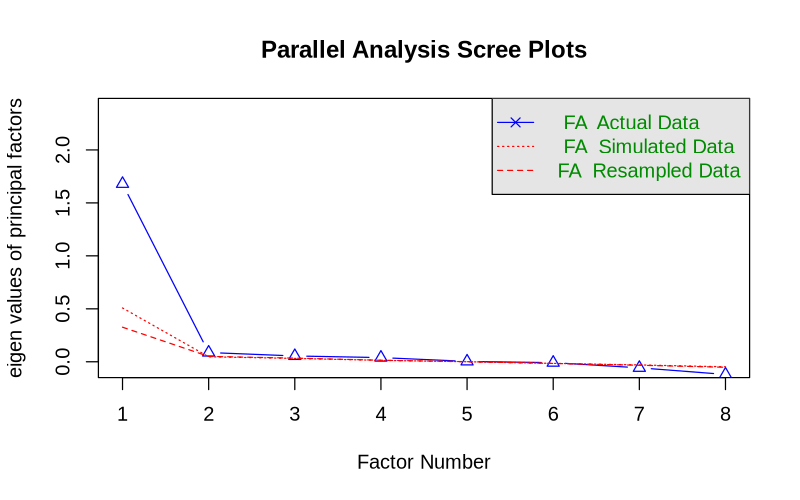

In [26]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 800, height = 500, res = 120,
    type = "cairo", family = "sans")

# Build the fa.parallel(...) call inside print(...). Use fa = "fa".

print(
  psych::fa.parallel(X_books_norm, fa = "fa")    # replace NULL with your fa.parallel(X_books_norm, fa = "fa", ...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 5 — EFA with Varimax Rotation, `nfactors = 2`

Store the result in `fa_books`. Print loadings with `cutoff = 0.30, sort = TRUE`.

In [27]:
# Required object: fa_books


fa_books <- psych::fa(X_books_norm, nfactors = 2, rotate = "varimax", fm = "ml")    # replace NULL with your code

print(fa_books$loadings, cutoff = 0.30, sort = TRUE)
fa_books$Vaccounted



Loadings:
         ML2   ML1  
ChildBks 0.607      
CookBks  0.674      
ArtBks         0.993
YouthBks 0.479      
DoItYBks 0.495      
RefBks   0.426      
GeogBks  0.368      
ItalCook            

                 ML2   ML1
SS loadings    1.655 1.003
Proportion Var 0.207 0.125
Cumulative Var 0.207 0.332


,ML2,ML1
SS loadings,1.6551,1.0030
Proportion Var,0.2069,0.1254
Cumulative Var,0.2069,0.3323
Proportion Explained,0.6227,0.3773
Cumulative Proportion,0.6227,1.0000


### Question 5 — Analysis Answer

*The KMO and Bartlett's test have shown that these 8 variables are ready for factor analysis. With a factor of 2, it was separated into a group for general reading and another for just for art books. This book club is really separated and maybe could use a higher factor, but the current groups are very diverse and should be marketed to other readers wanting to join.*


---


## Question 6 — Module 4.1b: Conjoint Analysis (Streaming Service)

A streaming service tests three attributes:
`Price` (\$8 / \$12 / \$16), `Resolution` (HD / 4K), `Ads` (Yes / No).
A focus-group respondent rated each of the 12 profiles on a 1 (worst) – 9 (best)
scale.

**Tasks:**
1. Build the 3 × 2 × 2 = 12 profile design dataframe (with the ratings vector below) → store in `profiles.df`
2. Estimate part-worth utilities by fitting `Rating ~ Price + Resolution + Ads` → store in `cj_lm`
3. Compute the part-worths (level mean − grand mean) → store in `partworth` (a named list, one element per attribute)
4. Compute attribute importance % (range / sum of ranges × 100) → store in `attr_importance`
5. Identify the **best** and **worst** predicted profiles → store in `best_profile` and `worst_profile`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Build the Profile Design and Add Ratings

Store in `profiles.df`. Use the ratings vector exactly as provided.

In [28]:
# Required object: profiles.df

profiles.df <- expand.grid(
  Price      = factor(c("$8","$12","$16"), levels = c("$8","$12","$16")),
  Resolution = factor(c("HD","4K")),
  Ads        = factor(c("Yes","No"))
)
profiles.df$Rating <- c(7, 5, 3,  9, 6,
                        8, 5, 2,  9, 7,
                        6, 4)        # 12 ratings provided

profiles.df


Price,Resolution,Ads,Rating
<fct>,<fct>,<fct>,<dbl>
$8,HD,Yes,7
$12,HD,Yes,5
$16,HD,Yes,3
$8,4K,Yes,9
$12,4K,Yes,6
$16,4K,Yes,8
$8,HD,No,5
$12,HD,No,2
$16,HD,No,9


### Step 2 — Linear Regression for Part-Worths

Store the model in `cj_lm`.

In [29]:
# Required object: cj_lm

cj_lm <- lm(Rating ~ Price + Resolution + Ads, data = profiles.df)    # replace NULL with your code

summary(cj_lm)



Call:
lm(formula = Rating ~ Price + Resolution + Ads, data = profiles.df)

Residuals:
   Min     1Q Median     3Q    Max 
-2.667 -1.021  0.208  0.833  4.167 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)     7.333      1.462    5.02   0.0015 **
Price$12       -2.250      1.602   -1.40   0.2029   
Price$16       -1.000      1.602   -0.62   0.5522   
ResolutionHD   -1.500      1.308   -1.15   0.2891   
AdsYes          0.833      1.308    0.64   0.5443   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.27 on 7 degrees of freedom
Multiple R-squared:  0.346,	Adjusted R-squared:  -0.0277 
F-statistic: 0.926 on 4 and 7 DF,  p-value: 0.5


### Step 3 — Compute Part-Worths

Store in `partworth` as a named list (one element per attribute) where each
element is a vector of (level mean − grand mean).

In [30]:
# Required object: partworth
grand_mean <- mean(profiles.df$Rating)

partworth <- list()
# Fill in partworth$Price, partworth$Resolution, partworth$Ads

partworth$Price      <- tapply(profiles.df$Rating, profiles.df$Price, mean) - grand_mean    # replace NULL with your code
partworth$Resolution <- tapply(profiles.df$Rating, profiles.df$Resolution, mean) - grand_mean    # replace NULL with your code
partworth$Ads        <- tapply(profiles.df$Rating, profiles.df$Ads, mean) - grand_mean    # replace NULL with your code

partworth


$Price
      $8      $12      $16 
 1.08333 -1.16667  0.08333 

$Resolution
   4K    HD 
 0.75 -0.75 

$Ads
     No     Yes 
-0.4167  0.4167

### Step 4 — Attribute Importance (%)

Store in `attr_importance` (a named numeric vector summing to ~100).

In [31]:
# Required object: attr_importance
ranges <- sapply(partworth, function(x) max(x) - min(x))

attr_importance <- (ranges / sum(ranges))    # replace NULL with your code
round(attr_importance, 1)


Price Resolution        Ads 
       0.5        0.3        0.2

### Step 5 — Best and Worst Predicted Profiles

Store in `best_profile` and `worst_profile`.

In [32]:
# Required objects: best_profile, worst_profile

profiles.df$Pred <- predict(cj_lm)
best_profile  <- profiles.df[which.max(profiles.df$Pred), ]    # replace NULL with your code
worst_profile <- profiles.df[which.min(profiles.df$Pred), ]    # replace NULL with your code

cat("BEST predicted profile:\n");  print(best_profile)
cat("\nWORST predicted profile:\n"); print(worst_profile)


BEST predicted profile:
  Price Resolution Ads Rating  Pred
4    $8         4K Yes      9 8.167

WORST predicted profile:
  Price Resolution Ads Rating  Pred
8   $12         HD  No      2 3.583


### Question 6 — Analysis Answer

*This shows that the Price is the most important factor at 50%, then comes resolution at 30%, and the Ads are only 20%. The best predicted profile is the 8 dollar, 4k, with Ads, and this goes to show people would much rather pay cheaper prices and have Ads. The worst profile is 12 dollar, HD, No Ads. The key takeaway for the business is that the service should prioritize lower prices and 4k as those would drive off the most customers*

---


## Question 7 — Module 5.0: Cluster Analysis on EastWestAirlines

**Dataset:** `mlba::EastWestAirlinesCluster` (3,999 frequent-flyers × 12 variables)

**Inputs (X):** the 10 behavioral variables — drop `ID.` and `Award.`.

**Tasks:**
1. Load the data, drop `ID.` and `Award.` → store in `ewa.df`; standardize → store in `X_ewa_norm`
2. Compute the Euclidean distance matrix → store in `d_ewa`
3. **Hierarchical clustering with Ward's linkage** (`method = "ward.D2"`) → store in `hc_ewa`; cut at `k = 4` → store labels in `Y_ewa_hier`
4. **K-means** with `centers = 4`, `nstart = 25`, `set.seed(42)` → store in `km_ewa`; store labels in `Y_ewa_km`
5. Cross-tabulate hierarchical vs k-means cluster labels
6. Profile the k-means clusters on the **original (unstandardized)** scale → store the table in `ewa_profile`
7. Plot the k-means cluster visualization (`fviz_cluster`)
8. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load, Drop ID/Award, Standardize

Store the cleaned dataframe in `ewa.df` and the standardized matrix in `X_ewa_norm`.

In [33]:
# Required objects: ewa.df, X_ewa_norm
ewa.df     <- mlba::EastWestAirlinesCluster[, !names(mlba::EastWestAirlinesCluster) %in% c("ID.", "Award.")]
X_ewa_norm <- scale(ewa.df)   # replace NULL with your code

cat("n =", nrow(ewa.df), " p =", ncol(ewa.df), "\n")


n = 3999  p = 10 


### Step 2 — Euclidean Distance Matrix

Store in `d_ewa`.

In [34]:
# Required object: d_ewa

d_ewa <- dist(X_ewa_norm, method = "euclidean")    # replace NULL with your code

### Step 3 — Hierarchical Clustering (Ward) and Cut at k = 4

Store the hclust object in `hc_ewa` and the cluster labels in `Y_ewa_hier`.

In [35]:
# Required objects: hc_ewa, Y_ewa_hier

hc_ewa     <- hclust(d_ewa, method = "ward.D2")    # replace NULL with your code   (method = "ward.D2")
Y_ewa_hier <- cutree(hc_ewa, k = 4)    # replace NULL with your code   (cutree at k = 4)

table(Y_ewa_hier)


Y_ewa_hier
   1    2    3    4 
2850 1010   43   96 

### Step 3b — Plot the Ward Dendrogram (with k = 4 boxes)

Use the cairo-PNG wrapper. Draw `plot(hc_ewa, labels = FALSE, ...)` and
overlay `rect.hclust(hc_ewa, k = 4, border = "red")`.

agg_record_1361106105 
                    2

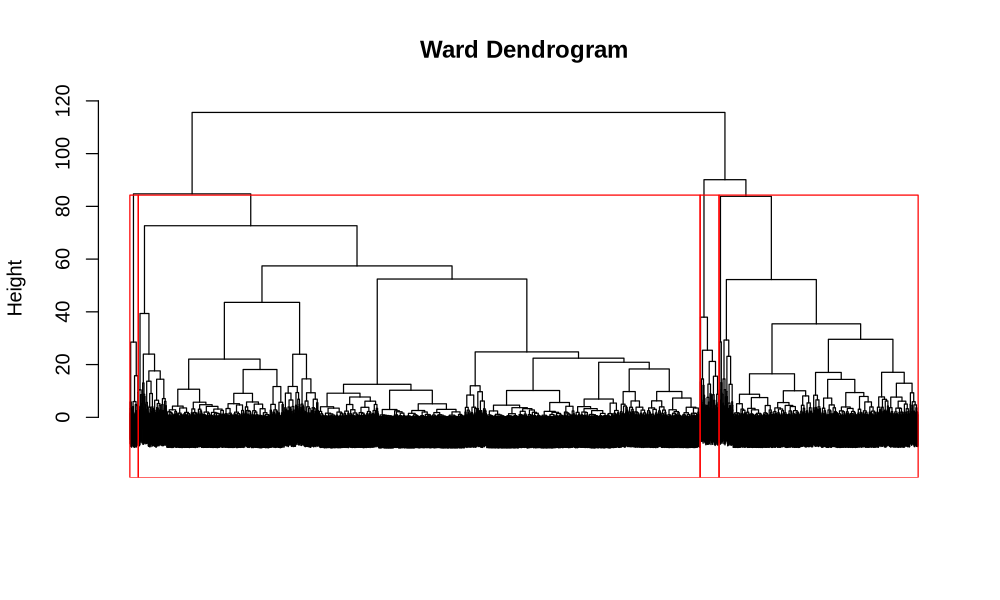

In [36]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 1000, height = 600, res = 120,
    type = "cairo", family = "sans")


plot(hc_ewa, labels = FALSE, main = "Ward Dendrogram", xlab = "", sub = "")    # replace NULL with your plot(...) call
rect.hclust(hc_ewa, k = 4, border = "red")    # replace NULL with your rect.hclust(...) call

dev.off()
IRdisplay::display_png(file = tmp_file)

### Step 4 — K-Means (k = 4)

Store the kmeans object in `km_ewa` and the labels in `Y_ewa_km`.

In [37]:
set.seed(42)
# Required objects: km_ewa, Y_ewa_km

km_ewa   <- kmeans(X_ewa_norm, centers = 4, nstart = 25)    # replace NULL with your code   (centers = 4, nstart = 25)
Y_ewa_km <- km_ewa$cluster    # replace NULL with your code

table(Y_ewa_km)


Y_ewa_km
   1    2    3    4 
  15 2479  160 1345 

### Step 5 — Cross-Tabulate Hierarchical vs K-Means

In [38]:
# Print a cross-tabulation of Y_ewa_hier (rows) vs Y_ewa_km (columns).

table(Y_ewa_hier, Y_ewa_km)    # replace NULL with your code


          Y_ewa_km
Y_ewa_hier    1    2    3    4
         1    0 2424   58  368
         2   15   17    6  972
         3    0   37    4    2
         4    0    1   92    3

### Step 6 — Cluster Profile (Original Scale)

Store the per-cluster mean table in `ewa_profile`.

In [39]:
# Required object: ewa_profile


ewa_profile <- aggregate(ewa.df, by = list(Cluster = Y_ewa_km), FUN = mean)    # replace NULL with your code
ewa_profile


Cluster,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,138061,78.8,3.467,1.000,4.067,93928,28.067,506.7,1.6000,4614
2,42759,105.0,1.162,1.020,1.000,4281,6.642,212.9,0.6482,3699
3,193027,802.8,2.181,1.038,1.000,31888,27.431,5455.5,16.0688,4712
4,115522,138.6,3.683,1.001,1.001,38244,18.677,320.8,0.9599,4817


### Step 7 — K-Means Cluster Visualization

agg_record_1944488234 
                    2

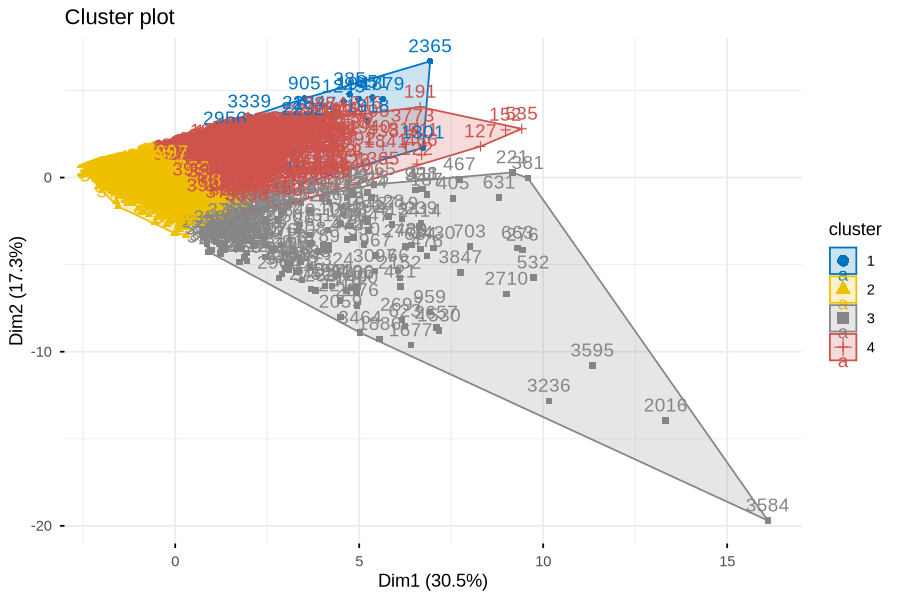

In [ ]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")


# Build the fviz_cluster(...) plot inside print(...).

print(
  factoextra::fviz_cluster(km_ewa, data = X_ewa_norm, ellipse.type = "convex", palette = "jco", ggtheme = ggplot2::theme_minimal())    # replace NULL with your fviz_cluster(km_ewa, data = X_ewa_norm, ...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 7 — Analysis Answer

*Out of the 4 groups, cluster 3 was the high balance frequent flyers, with the most miles and most transactions. Cluster 1 is the cluster with high bonus miles but they do not fly frequently, and Cluster 2 is the low flight low balance customers. Lastly cluster 4 is the moderate flyers with a good amount of bonus miles and a good balance aswell. The airline should do a loyalty program with cluster 3, and maybe an engaement again for cluster 2 because there are almost 2500 people in that cluster.*

---


## Question 8 — Module 5.1: Linear Discriminant Analysis on Banks

**Dataset:** `mlba::Banks` (20 banks × 5 variables)

**Inputs (X):** `TotCap.Assets`, `TotExp.Assets`, `TotLns.Lses.Assets`.

**Output (Y):** `Financial.Condition` recoded as a factor with labels
`c("Strong", "Weak")` (levels `0 = Strong, 1 = Weak`).

**Tasks:**
1. Load the data, drop `Obs`, recode `Financial.Condition` to a factor with labels `c("Strong","Weak")` → store in `banks.df`; create `X_banks` (3 predictors) and `Y_banks` (target factor)
2. Fit an **LDA**: `Financial.Condition ~ .` → store in `lda_banks`
3. Predict on the full data (n = 20 is too small to hold out) → store predicted classes in `Y_banks_pred`, the `caret::confusionMatrix` in `cm_banks`, and the overall accuracy in `accuracy_banks`
4. Predict the financial condition of a new bank with `TotCap.Assets = 8.0`, `TotExp.Assets = 0.11`, `TotLns.Lses.Assets = 0.55` → store the new observation in `new_bank` and the prediction in `pred_new_bank`
5. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Prepare Data

Store the cleaned dataframe in `banks.df`, predictors in `X_banks`, target in `Y_banks`.

In [47]:
# Required objects: banks.df, X_banks, Y_banks

banks.df <- mlba::Banks %>%
select(-Obs) %>%
  mutate(Financial.Condition = factor(Financial.Condition, levels = c(0, 1), labels = c("Strong", "Weak")))    # replace NULL with your code   (factor labels c("Strong","Weak"); drop Obs)
X_banks  <- banks.df %>% select(TotCap.Assets, TotExp.Assets, TotLns.Lses.Assets)    # replace NULL with your code   (3 numeric predictors)
Y_banks  <- banks.df$Financial.Condition    # replace NULL with your code   (target factor)

cat("Class balance:\n"); print(table(Y_banks))
banks.df


Class balance:
Y_banks
Strong   Weak 
    10     10 


Financial.Condition,TotCap.Assets,TotExp.Assets,TotLns.Lses.Assets
<fct>,<dbl>,<dbl>,<dbl>
Weak,9.7,0.12,0.65
Weak,1.0,0.11,0.62
Weak,6.9,0.09,1.02
Weak,5.8,0.10,0.67
Weak,4.3,0.11,0.69
Weak,9.1,0.13,0.74
Weak,11.9,0.10,0.79
Weak,8.1,0.13,0.63
Weak,9.3,0.16,0.72


### Step 2 — Fit the LDA Model

Store in `lda_banks`.

In [46]:
# Required object: lda_banks

lda_banks <- MASS::lda(Financial.Condition ~ ., data = banks.df)    # replace NULL with your code
lda_banks


Call:
lda(Financial.Condition ~ ., data = banks.df)

Prior probabilities of groups:
Strong   Weak 
   0.5    0.5 

Group means:
       TotCap.Assets TotExp.Assets TotLns.Lses.Assets
Strong         11.92         0.088              0.547
Weak            6.72         0.121              0.710

Coefficients of linear discriminants:
                      LD1
TotCap.Assets      -0.166
TotExp.Assets      35.107
TotLns.Lses.Assets  4.868

### Step 3 — Confusion Matrix on the Full Data

Store predictions in `Y_banks_pred`, confusion matrix in `cm_banks`, accuracy in `accuracy_banks`.

In [51]:
# Required objects: Y_banks_pred, cm_banks, accuracy_banks

Y_banks_pred   <- predict(lda_banks, banks.df)$class    # replace NULL with your code
cm_banks       <- caret::confusionMatrix(Y_banks_pred, Y_banks, positive = "Weak")    # replace NULL with your code   (caret::confusionMatrix)
accuracy_banks <- cm_banks$overall["Accuracy"]    # replace NULL with your code

cm_banks
cat("Overall accuracy:", round(accuracy_banks, 4), "\n")


Confusion Matrix and Statistics

          Reference
Prediction Strong Weak
    Strong      9    0
    Weak        1   10
                                        
               Accuracy : 0.95          
                 95% CI : (0.751, 0.999)
    No Information Rate : 0.5           
    P-Value [Acc > NIR] : 0.00002       
                                        
                  Kappa : 0.9           
                                        
 Mcnemar's Test P-Value : 1             
                                        
            Sensitivity : 1.000         
            Specificity : 0.900         
         Pos Pred Value : 0.909         
         Neg Pred Value : 1.000         
             Prevalence : 0.500         
         Detection Rate : 0.500         
   Detection Prevalence : 0.550         
      Balanced Accuracy : 0.950         
                                        
       'Positive' Class : Weak          
                                        

Overall accuracy: 0.95 


### Step 4 — Predict for a New Bank

Store the new observation in `new_bank` and the prediction in `pred_new_bank`.

In [50]:
# Required objects: new_bank, pred_new_bank

new_bank      <- data.frame(TotCap.Assets     = 8.0, TotExp.Assets     = 0.11, TotLns.Lses.Assets = 0.55) # replace NULL with your code   (data.frame with the 3 predictors)
pred_new_bank <- predict(lda_banks, new_bank)    # replace NULL with your code   (predict(lda_banks, new_bank))

cat("Predicted class:", as.character(pred_new_bank$class), "\n")
cat("Posterior probabilities:\n"); print(round(pred_new_bank$posterior, 4))


Predicted class: Weak 
Posterior probabilities:
  Strong   Weak
1 0.4788 0.5212


### Question 8 — Analysis Answer

*The LDA correctly classified 19 out of 20 of the banks, so it achieved a 95% accuracy. Strong banks have a higher capital ratio (11.92 vs 6.72) and a lower expense ratio than the weak banks. The model predicted the new bank to be weak with around a 52% probability. This can be used by people to predict and show early signs of when the bank fails.*

---


## Submission Checklist

Before submitting, verify that:

- [ ] All `# YOUR CODE HERE — delete this comment when you add your code` comments have been **removed**
- [ ] All `NULL` placeholders have been **replaced** with working code
- [ ] The notebook **runs top-to-bottom without errors** (Kernel → Restart & Run All)
- [ ] All eight `*Your answer here*` markdown cells have been replaced with your written interpretation
- [ ] Variable / object names match the **Required object names** table at the top of the notebook
